# "Predicción del riesgo de entrega tardía de órdenes de producción en una planta manufacturera"
## Proyecto Analítica Segundo Corte

- Juan David orozco
- David Peralta
- Samuel Robayo
- Juan Jose Campos

# 1. Negocio y problema

## 1.1. Contexto del problema

En entornos industriales de manufactura, el cumplimiento de los tiempos de entrega es un factor crítico para la competitividad y la eficiencia operativa de la empresa. Las órdenes de producción deben ejecutarse dentro de ventanas de tiempo definidas, considerando restricciones como capacidad de maquinaria, disponibilidad de operarios, tiempos de preparación, mantenimiento y condiciones de la cadena de suministro.

Sin embargo, en la práctica, las plantas manufactureras enfrentan retrasos recurrentes en la entrega de órdenes. Estos retrasos generan múltiples impactos negativos, entre ellos:

- Penalizaciones por incumplimiento de contratos
- Incremento de costos operativos (horas extra, reprogramación)
- Congestión en el sistema productivo
- Afectación en la satisfacción del cliente
- Pérdida de confiabilidad en la planificación

Desde la perspectiva de la ingeniería industrial, este problema está directamente relacionado con el balance de carga, la utilización de recursos y la estabilidad operativa del sistema productivo.

En este contexto, surge la necesidad de anticipar qué órdenes tienen mayor probabilidad de retrasarse, con el fin de tomar decisiones preventivas y mejorar la eficiencia del sistema.

## 1.2. Planteamiento del problema de analítica

El problema de negocio se traduce en el siguiente reto analítico:

¿Es posible predecir, a partir de variables operativas y de planificación, si una orden de producción será entregada tarde?

Para responder esta pregunta, se plantea un problema de machine learning de tipo clasificación binaria, donde se busca asignar a cada orden una de las siguientes categorías:

- 1 → La orden presenta entrega tardía
- 0 → La orden se entrega a tiempo

La variable objetivo del modelo es:

**entrega_tardia**

El objetivo del modelo es identificar patrones en los datos históricos que permitan anticipar comportamientos futuros, apoyando la toma de decisiones en el entorno productivo.

## 1.2. Planteamiento del problema de analítica

El problema de negocio se traduce en el siguiente reto analítico:

¿Es posible predecir, a partir de variables operativas y de planificación, si una orden de producción será entregada tarde?

Para responder esta pregunta, se plantea un problema de machine learning de tipo clasificación binaria, donde se busca asignar a cada orden una de las siguientes categorías:

- 1 → La orden presenta entrega tardía
- 0 → La orden se entrega a tiempo

La variable objetivo del modelo es:

**entrega_tardia**

El objetivo del modelo es identificar patrones en los datos históricos que permitan anticipar comportamientos futuros, apoyando la toma de decisiones en el entorno productivo.

## 1.3. Enfoque desde la ingeniería industrial

Desde la perspectiva de la ingeniería industrial, este problema no se limita a la predicción estadística, sino que implica comprender las dinámicas del sistema productivo.

Las variables disponibles representan diferentes dimensiones del proceso, tales como:

- Carga operativa (backlog, órdenes en cola)
- Utilización de recursos (uso de capacidad)
- Condiciones del proceso (variabilidad, tiempos)
- Factores organizacionales (prioridad, programación)
- Estado del sistema (mantenimiento, proveedores)

El modelo busca capturar cómo estas variables interactúan y generan condiciones que aumentan el riesgo de retraso.

En particular, se espera que situaciones de alta presión operativa, como la combinación de alto backlog y alta utilización de capacidad, incrementen significativamente la probabilidad de incumplimiento en las entregas.

## 1.4. Tipo de problema de machine learning

El problema corresponde a una clasificación supervisada, ya que se dispone de un conjunto de datos históricos con la variable objetivo conocida.

Las principales características del problema son:

- Tipo: Clasificación binaria
- Variable objetivo: entrega_tardia (0 o 1)
- Datos etiquetados: Sí (en el conjunto de entrenamiento)
- Objetivo: predecir la probabilidad de retraso en nuevas órdenes

Este tipo de modelo permite asignar probabilidades a cada orden, facilitando la priorización de decisiones en el sistema productivo.

## 1.5. Impacto de los errores de clasificación

En este problema, no todos los errores tienen el mismo impacto desde el punto de vista operacional.

Se distinguen dos tipos principales de error:

### Falsos Positivos (FP)
El modelo predice que una orden será tardía, pero en realidad no lo es.

Impacto:
- Generación de alertas innecesarias
- Posible sobreasignación de recursos
- Incremento en costos operativos menores

### Falsos Negativos (FN)
El modelo predice que una orden será a tiempo, pero en realidad se retrasa.

Impacto:
- Incumplimiento de entregas
- Penalizaciones contractuales
- Pérdida de confianza del cliente
- Reprogramaciones urgentes
- Aumento significativo de costos

Desde el punto de vista industrial, los falsos negativos representan el mayor riesgo, ya que implican no detectar a tiempo un problema real.

Por esta razón, el modelo debe priorizar la capacidad de identificar correctamente las órdenes con riesgo de retraso.

## 1.6. Criterio de evaluación del modelo

Dado el impacto diferencial de los errores, no es suficiente evaluar el modelo únicamente con accuracy.

En este contexto, se priorizan métricas como:

- Recall (sensibilidad): mide la capacidad de detectar órdenes tardías
- F1-score: balance entre precisión y recall

El recall es especialmente importante, ya que permite minimizar los falsos negativos.

Esto implica que el modelo puede tolerar cierto nivel de falsos positivos, siempre que logre identificar la mayor cantidad posible de órdenes con riesgo de retraso.

## 1.7. Valor del modelo en el contexto empresarial

La implementación de un modelo predictivo de este tipo permite a la empresa:

- Anticipar posibles retrasos en la producción
- Priorizar órdenes críticas
- Ajustar la programación de manera proactiva
- Optimizar la asignación de recursos
- Reducir costos asociados a incumplimientos

En lugar de reaccionar ante los problemas, la organización puede adoptar un enfoque preventivo basado en datos, mejorando su desempeño operativo y su nivel de servicio.

# 2. Preprocesamiento

## 2.1. Carga, revisión y entendimiento de la base de datos

Vamos a comenzar cargando la base de datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carga correcta (relativa, no absoluta)
train = pd.read_csv(r"datos_entrenamiento_proyecto.csv")
test = pd.read_csv(r"datos_testeo_estudiantes_sin_target.csv")

print("Train:", train.shape)
print("Test :", test.shape)

train.head()

Train: (1800, 22)
Test : (600, 21)


,id_orden,familia_producto,turno,nivel_automatizacion,prioridad,tamano_lote,num_operarios,experiencia_prom_operarios_anios,tiempo_setup_min,tiempo_ciclo_estandar_min,...,ordenes_en_cola,cambios_programacion_24h,porcentaje_retrabajo_historico,proveedor_critico_atrasado,mantenimiento_pendiente,dias_desde_ultimo_mantenimiento,backlog_horas,tiempo_inspeccion_min,firmeza_programacion_pct,entrega_tardia
0,OP-00650,A,manana,alto,alta,195.0,3,4.82,37.7,3.98,...,12,3,1.28,0,0,17.5,46.11,2.69,67.79,0
1,OP-01233,A,manana,bajo,alta,444.0,4,3.18,38.5,4.55,...,4,3,8.81,0,0,16.8,35.29,3.44,87.21,0
2,OP-00518,C,noche,alto,baja,216.0,4,5.59,39.0,4.25,...,13,0,6.45,0,0,26.2,31.22,2.73,70.52,0
3,OP-01421,A,manana,bajo,media,173.0,4,8.84,23.7,4.59,...,10,0,5.70,1,0,37.9,8.78,3.06,75.56,0
4,OP-01044,D,noche,medio,media,193.0,2,3.60,25.8,3.93,...,15,1,6.26,0,0,31.3,35.60,2.75,66.42,1


In [2]:
TARGET = "entrega_tardia"

print("¿Target en train?:", TARGET in train.columns)
print("¿Target en test? :", TARGET in test.columns)

¿Target en train?: True
¿Target en test? : False


El conjunto de entrenamiento contiene la variable objetivo entrega_tardia, mientras que el conjunto de prueba no la contiene, lo que confirma que este último debe utilizarse únicamente para evaluación final del modelo, evitando cualquier tipo de ajuste iterativo sobre él.

Ya tenemos cargada la base de datos correspondiente, ahora teniendo en cuenta que lo que diferencia mis datos de entrenamiento y prueba es la ausencia de nuestro target "entrega tardia", a continuacion los distinguiremos a partir de este criterio.

In [3]:
X = train.drop(TARGET, axis=1)
y = train[TARGET]

In [4]:
# ELIMINAR ID
X = X.drop("id_orden", axis=1)
test_ids = test["id_orden"]
test = test.drop("id_orden", axis=1)

Hecho esto, a continuación crearemos un diccionario de datos breve para facilitar el entendimiento de cada variable.

In [5]:
diccionario = pd.DataFrame([
    ("id_orden","ID","Identificador único de la orden"),
    ("familia_producto","Categórica","Familia del producto (A-E)"),
    ("turno","Categórica","Turno de producción (mañana/tarde/noche)"),
    ("nivel_automatizacion","Categórica","Nivel de automatización (bajo/medio/alto)"),
    ("prioridad","Categórica","Prioridad (alta/media/baja)"),
    ("tamano_lote","Numérica","Tamaño del lote"),
    ("num_operarios","Numérica Discreta","Número de operarios"),
    ("experiencia_prom_operarios_anios","Numérica","Experiencia promedio del equipo (años)"),
    ("tiempo_setup_min","Numérica","Tiempo de setup (min)"),
    ("tiempo_ciclo_estandar_min","Numérica","Tiempo ciclo estándar (min)"),
    ("variabilidad_proceso_pct","Numérica","Variabilidad del proceso (%)"),
    ("uso_capacidad_pct","Numérica","Uso de capacidad (%)"),
    ("ordenes_en_cola","Numérica Discreta","Órdenes en cola"),
    ("cambios_programacion_24h","Numérica Discreta","Cambios de programación últimas 24h"),
    ("porcentaje_retrabajo_historico","Numérica","Retrabajo histórico (%)"),
    ("proveedor_critico_atrasado","Binaria","1=proveedor crítico atrasado; 0=no"),
    ("mantenimiento_pendiente","Binaria","1=mantenimiento pendiente; 0=no"),
    ("dias_desde_ultimo_mantenimiento","Numérica","Días desde último mantenimiento"),
    ("backlog_horas","Numérica","Backlog (horas)"),
    ("tiempo_inspeccion_min","Numérica","Tiempo de inspección (min)"),
    ("firmeza_programacion_pct","Numérica","Firmeza de programación (%)"),
    ("entrega_tardia","Objetivo (binaria)","1=tardía; 0=a tiempo (solo en train)"),
], columns=["Variable","Tipo","Descripción"])

display(diccionario)

,Variable,Tipo,Descripción
0,id_orden,ID,Identificador único de la orden
1,familia_producto,Categórica,Familia del producto (A-E)
2,turno,Categórica,Turno de producción (mañana/tarde/noche)
3,nivel_automatizacion,Categórica,Nivel de automatización (bajo/medio/alto)
4,prioridad,Categórica,Prioridad (alta/media/baja)
5,tamano_lote,Numérica,Tamaño del lote
6,num_operarios,Numérica Discreta,Número de operarios
7,experiencia_prom_operarios_anios,Numérica,Experiencia promedio del equipo (años)
8,tiempo_setup_min,Numérica,Tiempo de setup (min)
9,tiempo_ciclo_estandar_min,Numérica,Tiempo ciclo estándar (min)


Bajo este diccionario, ya sabemos que tipo de variable se va a tratar y su respectivo significado. Ahora vamos a verificar el tipo de datos desde la perspectiva computacional, posibles inconsistencias y la estructura general del conjunto.

In [6]:
# Tipo de dato y estructura
print("INFO TRAIN")
train.info()

INFO TRAIN
<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_orden                          1800 non-null   str    
 1   familia_producto                  1800 non-null   str    
 2   turno                             1800 non-null   str    
 3   nivel_automatizacion              1800 non-null   str    
 4   prioridad                         1800 non-null   str    
 5   tamano_lote                       1800 non-null   float64
 6   num_operarios                     1800 non-null   int64  
 7   experiencia_prom_operarios_anios  1696 non-null   float64
 8   tiempo_setup_min                  1726 non-null   float64
 9   tiempo_ciclo_estandar_min         1800 non-null   float64
 10  variabilidad_proceso_pct          1685 non-null   float64
 11  uso_capacidad_pct                 1733 non-null   float64
 12  ordene

In [7]:
print("\nINFO TEST")
test.info()


INFO TEST
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   familia_producto                  600 non-null    str    
 1   turno                             600 non-null    str    
 2   nivel_automatizacion              600 non-null    str    
 3   prioridad                         600 non-null    str    
 4   tamano_lote                       600 non-null    float64
 5   num_operarios                     600 non-null    int64  
 6   experiencia_prom_operarios_anios  575 non-null    float64
 7   tiempo_setup_min                  578 non-null    float64
 8   tiempo_ciclo_estandar_min         600 non-null    float64
 9   variabilidad_proceso_pct          571 non-null    float64
 10  uso_capacidad_pct                 575 non-null    float64
 11  ordenes_en_cola                   600 non-null    int64  
 12  cambios_

In [8]:
print("\nTipos TRAIN:\n", train.dtypes)
print("\nTipos TEST:\n", test.dtypes)


Tipos TRAIN:
 id_orden                                str
familia_producto                        str
turno                                   str
nivel_automatizacion                    str
prioridad                               str
tamano_lote                         float64
num_operarios                         int64
experiencia_prom_operarios_anios    float64
tiempo_setup_min                    float64
tiempo_ciclo_estandar_min           float64
variabilidad_proceso_pct            float64
uso_capacidad_pct                   float64
ordenes_en_cola                       int64
cambios_programacion_24h              int64
porcentaje_retrabajo_historico      float64
proveedor_critico_atrasado            int64
mantenimiento_pendiente               int64
dias_desde_ultimo_mantenimiento     float64
backlog_horas                       float64
tiempo_inspeccion_min               float64
firmeza_programacion_pct            float64
entrega_tardia                        int64
dtype: object

Ti

In [9]:
# Valores faltantes
def resumen_nulos(df):
    nulos = df.isna().sum()
    pct = (df.isna().mean()*100).round(2)
    out = pd.DataFrame({"nulos": nulos, "%": pct})
    return out[out["nulos"]>0].sort_values("nulos", ascending=False)

In [10]:
print("Nulos en TRAIN:")
display(resumen_nulos(train))

Nulos en TRAIN:


,nulos,%
variabilidad_proceso_pct,115,6.39
porcentaje_retrabajo_historico,108,6.00
experiencia_prom_operarios_anios,104,5.78
tiempo_setup_min,74,4.11
uso_capacidad_pct,67,3.72
firmeza_programacion_pct,65,3.61


In [11]:
print("Nulos en TEST:")
display(resumen_nulos(test))

Nulos en TEST:


,nulos,%
porcentaje_retrabajo_historico,30,5.00
variabilidad_proceso_pct,29,4.83
uso_capacidad_pct,25,4.17
experiencia_prom_operarios_anios,25,4.17
tiempo_setup_min,22,3.67
firmeza_programacion_pct,22,3.67


In [12]:
# Duplicados
print("Duplicados por fila - train:", train.duplicated().sum())
print("Duplicados por fila - test :", test.duplicated().sum())

Duplicados por fila - train: 0
Duplicados por fila - test : 0


In [13]:
print("IDs duplicados - train:", train["id_orden"].duplicated().sum())
print("IDs duplicados - test :", test.duplicated().sum())

IDs duplicados - train: 0
IDs duplicados - test : 0


In [14]:
#Revision de categorias (Valores únicos)
cat_cols = train.select_dtypes(include="object").columns
for col in cat_cols:
    print("\n", col)
    print(train[col].value_counts())


 id_orden
id_orden
OP-00650    1
OP-01233    1
OP-00518    1
OP-01421    1
OP-01044    1
           ..
OP-02247    1
OP-01396    1
OP-02017    1
OP-00782    1
OP-00315    1
Name: count, Length: 1800, dtype: int64

 familia_producto
familia_producto
A    411
B    397
C    349
D    346
E    297
Name: count, dtype: int64

 turno
turno
manana    778
tarde     647
noche     375
Name: count, dtype: int64

 nivel_automatizacion
nivel_automatizacion
medio    832
bajo     493
alto     475
Name: count, dtype: int64

 prioridad
prioridad
media    881
baja     472
alta     447
Name: count, dtype: int64


C:\Users\juanj\AppData\Local\Temp\ipykernel_26468\2378914965.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include="object").columns


In [15]:
# Balance de variable objetivo
TARGET = "entrega_tardia"
display(train[TARGET].value_counts().to_frame("conteo"))
display((train[TARGET].value_counts(normalize=True)*100).round(2).to_frame("%"))

,conteo
entrega_tardia,
0,1146
1,654


,%
entrega_tardia,
0,63.67
1,36.33


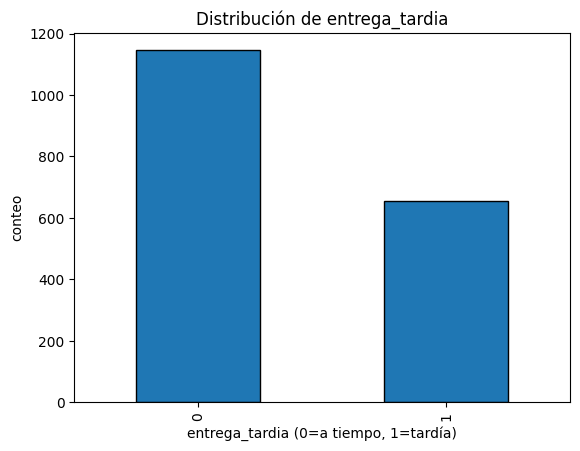

In [16]:
plt.figure()
train[TARGET].value_counts().plot(kind="bar", edgecolor="black")
plt.title("Distribución de entrega_tardia")
plt.xlabel("entrega_tardia (0=a tiempo, 1=tardía)")
plt.ylabel("conteo")
plt.show()

## 2.1 Preprocesamiento de Datos

Vamos a comenzar cargando los datos de ambos conjuntos y tratando los datos faltantes

In [17]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Rutas de los archivos originales
train_path = "datos_entrenamiento_proyecto.csv"
test_path = "datos_testeo_estudiantes_sin_target.csv"

# Cargar los datos de ambos conjuntos
df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

# Seleccionar columnas numéricas
num_cols_train = df_train.select_dtypes(include="number").columns.tolist()
num_cols_test  = df_test.select_dtypes(include="number").columns.tolist()

# Obtener la intersección de columnas numéricas presentes en ambos para imputar consistentemente
num_cols_to_impute = sorted(list(set(num_cols_train).intersection(set(num_cols_test))))

print("Columnas numéricas a imputar:", num_cols_to_impute)

# Crear el imputador (media) y ajustarlo solo con el conjunto de entrenamiento
imputer = SimpleImputer(strategy="mean")
imputer.fit(df_train[num_cols_to_impute])

# Crear copias para almacenar los datos imputados
df_train_imputed_new = df_train.copy()
df_test_imputed_new  = df_test.copy()

# Transformar (imputar) ambos conjuntos
df_train_imputed_new[num_cols_to_impute] = imputer.transform(df_train[num_cols_to_impute])
df_test_imputed_new[num_cols_to_impute]  = imputer.transform(df_test[num_cols_to_impute])

# Comprobar si aún quedan valores faltantes en las columnas imputadas
print("\nFaltantes numéricos (train) después de la nueva imputación:", df_train_imputed_new[num_cols_to_impute].isna().sum().sum())
print("Faltantes numéricos (test) después de la nueva imputación:", df_test_imputed_new[num_cols_to_impute].isna().sum().sum())

Columnas numéricas a imputar: ['backlog_horas', 'cambios_programacion_24h', 'dias_desde_ultimo_mantenimiento', 'experiencia_prom_operarios_anios', 'firmeza_programacion_pct', 'mantenimiento_pendiente', 'num_operarios', 'ordenes_en_cola', 'porcentaje_retrabajo_historico', 'proveedor_critico_atrasado', 'tamano_lote', 'tiempo_ciclo_estandar_min', 'tiempo_inspeccion_min', 'tiempo_setup_min', 'uso_capacidad_pct', 'variabilidad_proceso_pct']

Faltantes numéricos (train) después de la nueva imputación: 0
Faltantes numéricos (test) después de la nueva imputación: 0


## 2.2. Detección y Manejo de Atípicos

Para manejar los valores atípicos, utilizaremos el método del rango intercuartílico (IQR). Este método es robusto y se basa en la distribución de los datos, identificando como atípicos aquellos valores que se encuentran fuera de un rango determinado (generalmente 1.5 veces el IQR por debajo del primer cuartil o por encima del tercer cuartil). Los valores atípicos detectados serán reemplazados por la mediana de su respectiva columna, ya que la mediana es menos sensible a los extremos que la media.

In [18]:
import numpy as np

TARGET = "entrega_tardia"

# Identificar columnas numéricas para la detección de atípicos
# Usamos las columnas numéricas que ya hemos considerado para imputación, excluyendo el target si está presente
num_cols_for_outliers = [col for col in num_cols_to_impute if col != TARGET]

def handle_outliers_iqr(df, columns):
    df_copy = df.copy()
    for col in columns:
        if col in df_copy.columns:
            Q1 = df_copy[col].quantile(0.25)
            Q3 = df_copy[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Reemplazar atípicos con la mediana de la columna
            median_val = df_copy[col].median()
            df_copy.loc[df_copy[col] < lower_bound, col] = median_val
            df_copy.loc[df_copy[col] > upper_bound, col] = median_val
    return df_copy

# Aplicar la función a los dataframes imputados
df_train_cleaned = handle_outliers_iqr(df_train_imputed_new, num_cols_for_outliers)
df_test_cleaned  = handle_outliers_iqr(df_test_imputed_new, num_cols_for_outliers)

print("Valores atípicos detectados y manejados en las columnas numéricas.")
print("Primeras 5 filas del dataframe de entrenamiento después del manejo de atípicos:")
display(df_train_cleaned.head())

Valores atípicos detectados y manejados en las columnas numéricas.
Primeras 5 filas del dataframe de entrenamiento después del manejo de atípicos:


,id_orden,familia_producto,turno,nivel_automatizacion,prioridad,tamano_lote,num_operarios,experiencia_prom_operarios_anios,tiempo_setup_min,tiempo_ciclo_estandar_min,...,ordenes_en_cola,cambios_programacion_24h,porcentaje_retrabajo_historico,proveedor_critico_atrasado,mantenimiento_pendiente,dias_desde_ultimo_mantenimiento,backlog_horas,tiempo_inspeccion_min,firmeza_programacion_pct,entrega_tardia
0,OP-00650,A,manana,alto,alta,195.0,3.0,4.82,37.7,3.98,...,12.0,3.0,1.28,0.0,0.0,17.5,46.11,2.69,67.79,0
1,OP-01233,A,manana,bajo,alta,180.0,4.0,3.18,38.5,4.55,...,4.0,3.0,8.81,0.0,0.0,16.8,35.29,3.44,87.21,0
2,OP-00518,C,noche,alto,baja,216.0,4.0,5.59,39.0,4.25,...,13.0,0.0,6.45,0.0,0.0,26.2,31.22,2.73,70.52,0
3,OP-01421,A,manana,bajo,media,173.0,4.0,8.84,23.7,4.59,...,10.0,0.0,5.70,0.0,0.0,37.9,8.78,3.06,75.56,0
4,OP-01044,D,noche,medio,media,193.0,2.0,3.60,25.8,3.93,...,15.0,1.0,6.26,0.0,0.0,31.3,35.60,2.75,66.42,1


Los valores atípicos en las columnas numéricas han sido identificados y reemplazados por la mediana, lo que resulta en un conjunto de datos más robusto para el modelado. Esta técnica ayuda a mitigar el impacto de valores extremos en el rendimiento del modelo.

## 2.3. Transformación de Variables Categóricas

Para las variables categóricas, utilizaremos la técnica de "One-Hot Encoding". Esta transformación convierte cada categoría en una nueva columna binaria, lo que permite que los modelos de machine learning puedan procesarlas adecuadamente. Es importante aplicar esta transformación de manera consistente tanto al conjunto de entrenamiento como al de prueba.

In [19]:
# Identificar columnas categóricas
cat_cols = df_train_cleaned.select_dtypes(include='object').columns.tolist()

# Excluir 'id_orden' si aún está presente y no se desea codificar
if 'id_orden' in cat_cols:
    cat_cols.remove('id_orden')

print(f"Columnas categóricas a transformar: {cat_cols}")

# Aplicar One-Hot Encoding al conjunto de entrenamiento
df_train_encoded = pd.get_dummies(df_train_cleaned, columns=cat_cols, drop_first=True)

# Aplicar One-Hot Encoding al conjunto de prueba
df_test_encoded = pd.get_dummies(df_test_cleaned, columns=cat_cols, drop_first=True)

# Alinear las columnas de ambos dataframes después del encoding
# Esto es crucial para asegurar que ambos conjuntos tengan las mismas columnas en el mismo orden
train_cols = set(df_train_encoded.columns)
test_cols = set(df_test_encoded.columns)

missing_in_test = list(train_cols - test_cols)
for col in missing_in_test:
    df_test_encoded[col] = 0

missing_in_train = list(test_cols - train_cols)
for col in missing_in_train:
    df_train_encoded[col] = 0

# Asegurarse de que el orden de las columnas sea el mismo
df_test_encoded = df_test_encoded[df_train_encoded.columns]

print("\nPrimeras 5 filas del dataframe de entrenamiento después del One-Hot Encoding:")
display(df_train_encoded.head())

print("\nPrimeras 5 filas del dataframe de prueba después del One-Hot Encoding:")
display(df_test_encoded.head())

Columnas categóricas a transformar: ['familia_producto', 'turno', 'nivel_automatizacion', 'prioridad']

Primeras 5 filas del dataframe de entrenamiento después del One-Hot Encoding:


C:\Users\juanj\AppData\Local\Temp\ipykernel_26468\3930797845.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_train_cleaned.select_dtypes(include='object').columns.tolist()


,id_orden,tamano_lote,num_operarios,experiencia_prom_operarios_anios,tiempo_setup_min,tiempo_ciclo_estandar_min,variabilidad_proceso_pct,uso_capacidad_pct,ordenes_en_cola,cambios_programacion_24h,...,familia_producto_B,familia_producto_C,familia_producto_D,familia_producto_E,turno_noche,turno_tarde,nivel_automatizacion_bajo,nivel_automatizacion_medio,prioridad_baja,prioridad_media
0,OP-00650,195.0,3.0,4.82,37.7,3.98,13.46,71.31,12.0,3.0,...,False,False,False,False,False,False,False,False,False,False
1,OP-01233,180.0,4.0,3.18,38.5,4.55,6.60,65.96,4.0,3.0,...,False,False,False,False,False,False,True,False,False,False
2,OP-00518,216.0,4.0,5.59,39.0,4.25,9.83,79.46,13.0,0.0,...,False,True,False,False,True,False,False,False,True,False
3,OP-01421,173.0,4.0,8.84,23.7,4.59,9.59,66.06,10.0,0.0,...,False,False,False,False,False,False,True,False,False,True
4,OP-01044,193.0,2.0,3.60,25.8,3.93,13.54,72.27,15.0,1.0,...,False,False,True,False,True,False,False,True,False,True



Primeras 5 filas del dataframe de prueba después del One-Hot Encoding:


,id_orden,tamano_lote,num_operarios,experiencia_prom_operarios_anios,tiempo_setup_min,tiempo_ciclo_estandar_min,variabilidad_proceso_pct,uso_capacidad_pct,ordenes_en_cola,cambios_programacion_24h,...,familia_producto_B,familia_producto_C,familia_producto_D,familia_producto_E,turno_noche,turno_tarde,nivel_automatizacion_bajo,nivel_automatizacion_medio,prioridad_baja,prioridad_media
0,OP-01501,93.0,6.0,10.060000,46.6,3.79,15.000000,59.76,9.0,2.0,...,False,False,False,False,False,False,True,False,False,True
1,OP-01529,262.0,3.0,5.826733,44.4,4.39,16.600000,83.09,20.0,1.0,...,False,False,False,True,False,False,False,False,True,False
2,OP-00493,132.0,4.0,5.530000,54.1,4.51,10.970000,81.23,25.0,2.0,...,False,False,True,False,True,False,False,True,True,False
3,OP-00060,135.0,6.0,2.160000,77.9,3.97,11.558599,100.00,17.0,1.0,...,False,False,True,False,False,False,True,False,False,True
4,OP-00203,183.0,2.0,1.830000,43.7,5.36,9.250000,63.80,12.0,4.0,...,False,False,False,False,False,True,True,False,False,False


## 2.4. Estandarización de Variables Numéricas

La estandarización es un paso crucial en el preprocesamiento de datos, especialmente para algoritmos sensibles a la escala de las características (como la regresión logística y las redes neuronales). Utilizaremos `StandardScaler` para transformar los datos de manera que tengan una media de 0 y una desviación estándar de 1. Es importante ajustar el `StandardScaler` solo con el conjunto de entrenamiento y luego aplicarlo tanto al entrenamiento como al conjunto de prueba para evitar el "data leakage" (fuga de información).

In [20]:
from sklearn.preprocessing import StandardScaler

# Identificar y separar las características (X) y la variable objetivo (y) de los dataframes codificados
# 'id_orden' es un identificador y 'entrega_tardia' es la variable objetivo, que no debe escalarse.

# Crear conjuntos de características para entrenamiento y prueba, excluyendo 'id_orden' y 'entrega_tardia'
X_train_features_for_scaling = df_train_encoded.drop(columns=['id_orden', 'entrega_tardia'], errors='ignore')
X_test_features_for_scaling = df_test_encoded.drop(columns=['id_orden', 'entrega_tardia'], errors='ignore')

# Asegurar que las columnas de los conjuntos de características estén alineadas
# Esto es crucial para que el scaler vea las mismas columnas en ambos conjuntos
train_feature_cols = X_train_features_for_scaling.columns
test_feature_cols = X_test_features_for_scaling.columns

# Añadir columnas faltantes en el conjunto de prueba con valor 0
missing_in_test_feats = list(train_feature_cols.difference(test_feature_cols))
for col in missing_in_test_feats:
    X_test_features_for_scaling[col] = 0

# Añadir columnas faltantes en el conjunto de entrenamiento con valor 0 (si las hubiera, aunque no debería con el flujo actual)
missing_in_train_feats = list(test_feature_cols.difference(train_feature_cols))
for col in missing_in_train_feats:
    X_train_features_for_scaling[col] = 0

# Asegurarse de que el orden de las columnas sea el mismo en ambos conjuntos
X_test_features_for_scaling = X_test_features_for_scaling[train_feature_cols]

# Crear una instancia del StandardScaler
scaler = StandardScaler()

# Ajustar el scaler solo con las características de entrenamiento y transformar ambos conjuntos
X_train_scaled_features = scaler.fit_transform(X_train_features_for_scaling)
X_test_scaled_features = scaler.transform(X_test_features_for_scaling)

# Reconstruir los dataframes con las características escaladas y mantener las columnas no escaladas (como id_orden y entrega_tardia)
df_train_scaled = df_train_encoded.copy()
df_test_scaled = df_test_encoded.copy()

df_train_scaled[train_feature_cols] = X_train_scaled_features
df_test_scaled[train_feature_cols] = X_test_scaled_features

print("Variables numéricas estandarizadas.")
print("\nPrimeras 5 filas del dataframe de entrenamiento después de la estandarización:")
display(df_train_scaled.head())

print("\nPrimeras 5 filas del dataframe de prueba después de la estandarización:")
display(df_test_scaled.head())

Variables numéricas estandarizadas.

Primeras 5 filas del dataframe de entrenamiento después de la estandarización:


,id_orden,tamano_lote,num_operarios,experiencia_prom_operarios_anios,tiempo_setup_min,tiempo_ciclo_estandar_min,variabilidad_proceso_pct,uso_capacidad_pct,ordenes_en_cola,cambios_programacion_24h,...,familia_producto_B,familia_producto_C,familia_producto_D,familia_producto_E,turno_noche,turno_tarde,nivel_automatizacion_bajo,nivel_automatizacion_medio,prioridad_baja,prioridad_media
0,OP-00650,0.136113,-1.490325,-0.419690,-0.484785,0.078948,0.490001,-0.444561,-0.725809,0.721689,...,-0.531945,-0.490432,-0.487816,-0.444528,-0.512989,-0.749096,-0.614166,-0.927094,-0.596173,-0.979107
1,OP-01233,-0.073149,-0.864868,-1.156315,-0.428614,0.697891,-1.144989,-0.942607,-1.813277,0.721689,...,-0.531945,-0.490432,-0.487816,-0.444528,-0.512989,-0.749096,1.628225,-0.927094,-0.596173,-0.979107
2,OP-00518,0.429080,-0.864868,-0.073836,-0.393507,0.372132,-0.375162,0.314146,-0.589876,-1.473873,...,-0.531945,2.039018,-0.487816,-0.444528,1.949359,-0.749096,-0.614166,-0.927094,1.677367,-0.979107
3,OP-01421,-0.170804,-0.864868,1.385938,-1.467780,0.741325,-0.432362,-0.933298,-0.997676,-1.473873,...,-0.531945,-0.490432,-0.487816,-0.444528,-0.512989,-0.749096,1.628225,-0.927094,-0.596173,1.021339
4,OP-01044,0.108212,-2.115783,-0.967667,-1.320330,0.024655,0.509068,-0.355191,-0.318009,-0.742019,...,-0.531945,-0.490432,2.049954,-0.444528,1.949359,-0.749096,-0.614166,1.078639,-0.596173,1.021339



Primeras 5 filas del dataframe de prueba después de la estandarización:


,id_orden,tamano_lote,num_operarios,experiencia_prom_operarios_anios,tiempo_setup_min,tiempo_ciclo_estandar_min,variabilidad_proceso_pct,uso_capacidad_pct,ordenes_en_cola,cambios_programacion_24h,...,familia_producto_B,familia_producto_C,familia_producto_D,familia_producto_E,turno_noche,turno_tarde,nivel_automatizacion_bajo,nivel_automatizacion_medio,prioridad_baja,prioridad_media
0,OP-01501,-1.286867,0.386046,1.933915,0.140118,-0.127366,0.857039,-1.519783,-1.133610,-0.010165,...,-0.531945,-0.490432,-0.487816,-0.444528,-0.512989,-0.749096,1.628225,-0.927094,-0.596173,1.021339
1,OP-01529,1.070816,-1.490325,0.032496,-0.014352,0.524152,1.238378,0.652073,0.361659,-0.742019,...,-0.531945,-0.490432,-0.487816,2.249579,-0.512989,-0.749096,-0.614166,-0.927094,1.677367,-0.979107
2,OP-00493,-0.742787,-0.864868,-0.100786,0.666722,0.654456,-0.103458,0.478920,1.041326,-0.010165,...,-0.531945,-0.490432,2.049954,-0.444528,1.949359,-0.749096,-0.614166,1.078639,1.677367,-0.979107
3,OP-00060,-0.700934,0.386046,-1.614459,2.337813,0.068090,0.036827,2.226273,-0.046142,-0.742019,...,-0.531945,-0.490432,2.049954,-0.444528,-0.512989,-0.749096,1.628225,-0.927094,-0.596173,1.021339
4,OP-00203,-0.031296,-2.115783,-1.762682,-0.063502,1.577440,-0.513397,-1.143688,-0.725809,1.453543,...,-0.531945,-0.490432,-0.487816,-0.444528,-0.512989,1.334942,1.628225,-0.927094,-0.596173,-0.979107


## 2.5. Análisis de Colinealidad y Relevancia de Variables

Después del preprocesamiento, es fundamental revisar la colinealidad entre las variables y su relevancia para la variable objetivo. La colinealidad puede afectar la interpretabilidad de los modelos y la estabilidad de sus coeficientes. Este análisis nos ayudará a identificar si hay variables redundantes o que no aportan información única.

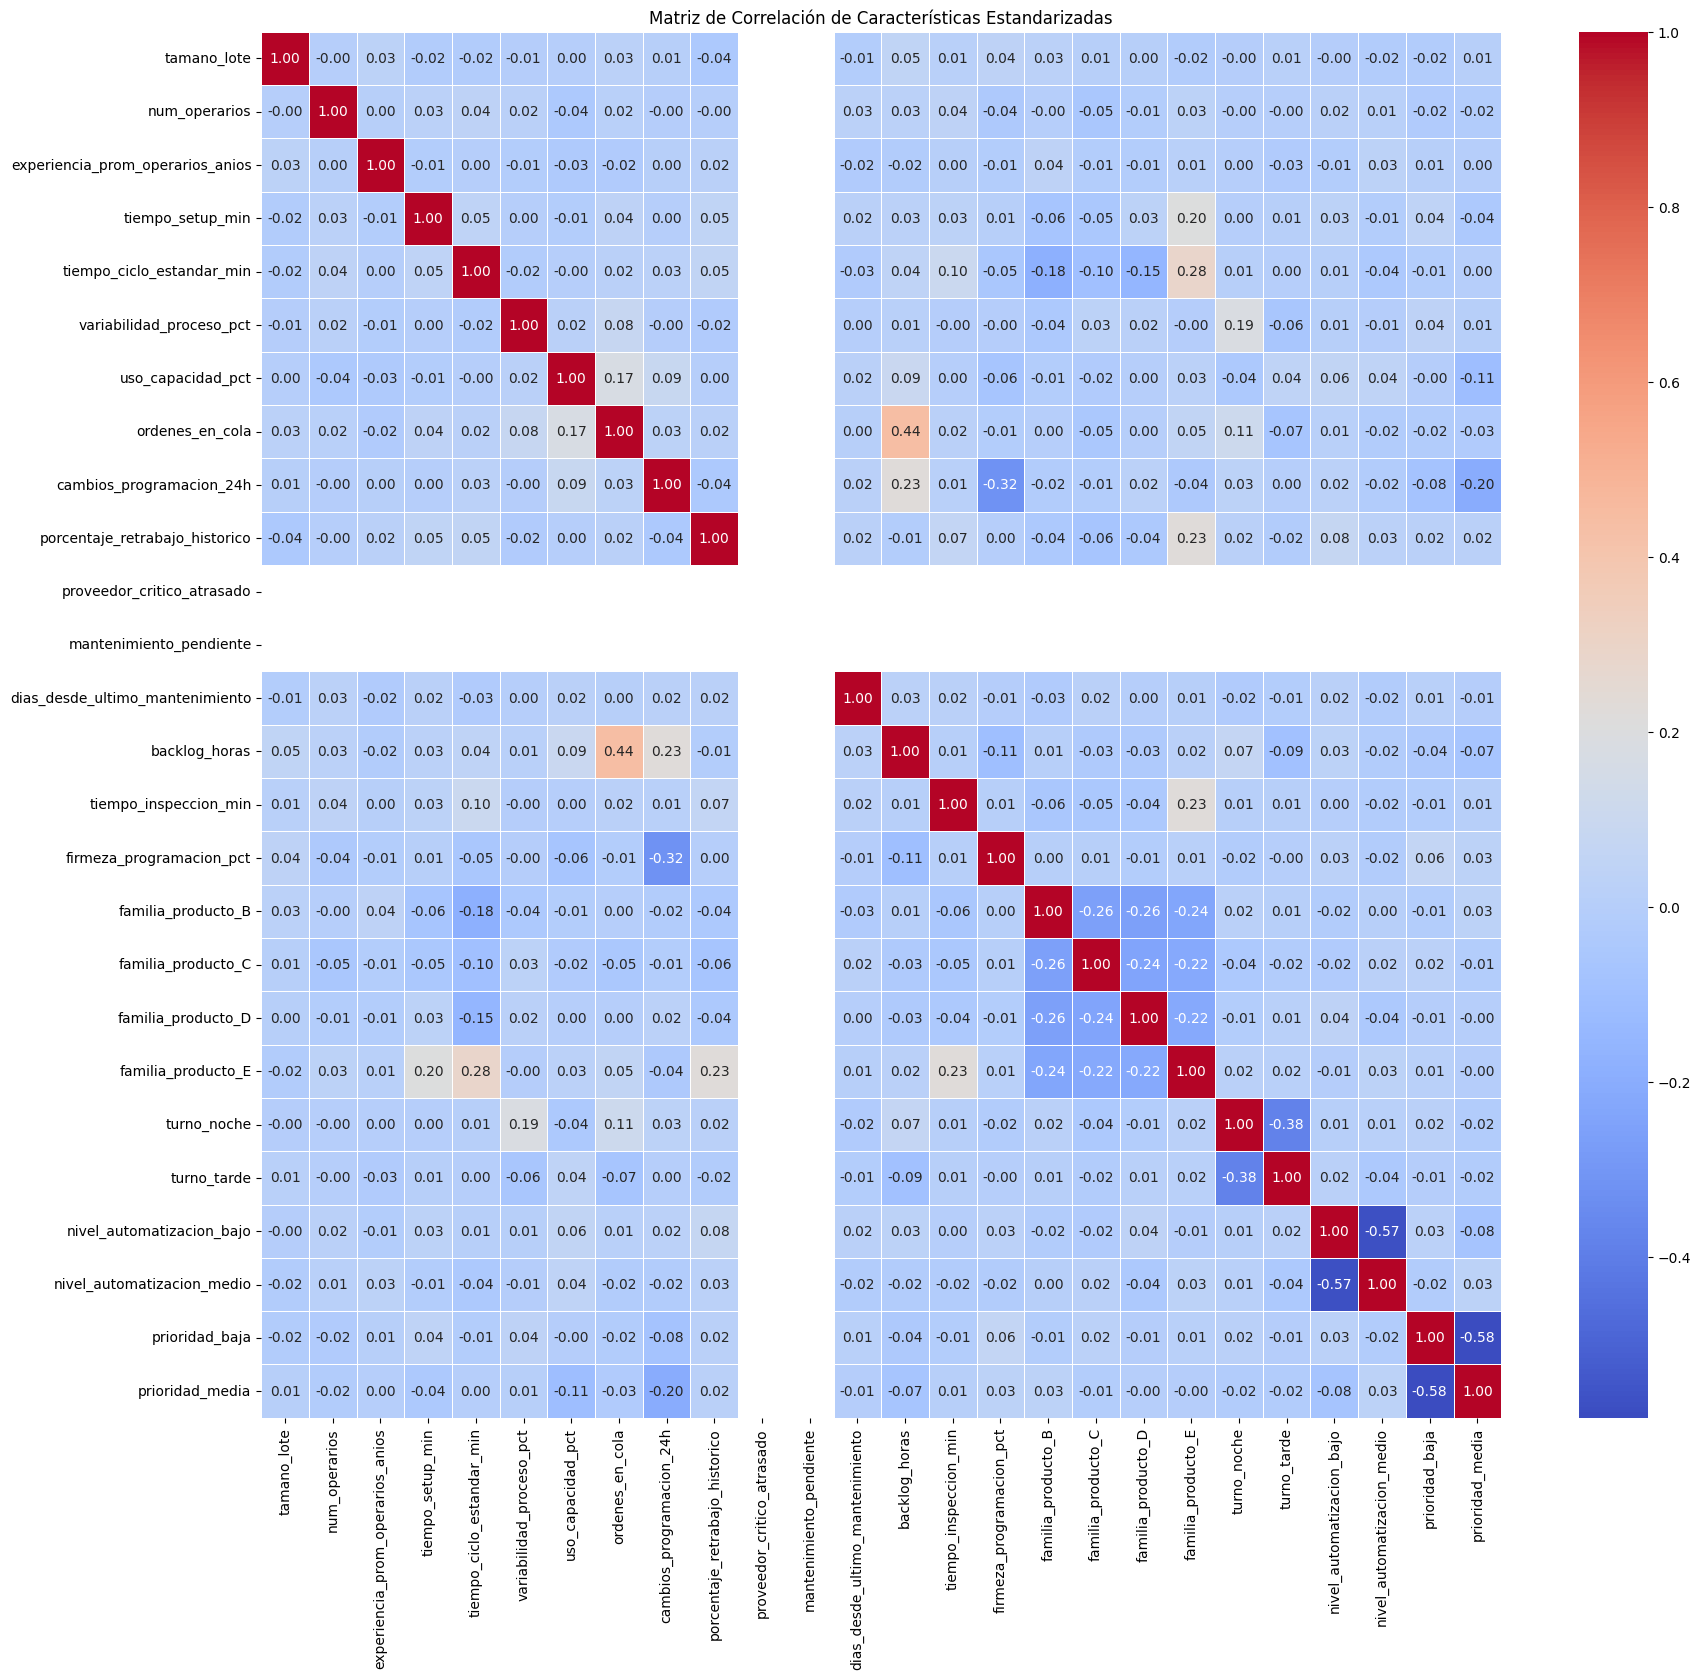

Top 10 pares de características más correlacionadas (valor absoluto):
prioridad_baja             prioridad_media               0.583717
nivel_automatizacion_bajo  nivel_automatizacion_medio    0.569390
ordenes_en_cola            backlog_horas                 0.441067
turno_noche                turno_tarde                   0.384278
cambios_programacion_24h   firmeza_programacion_pct      0.319309
tiempo_ciclo_estandar_min  familia_producto_E            0.282546
familia_producto_B         familia_producto_C            0.260883
                           familia_producto_D            0.259491
familia_producto_C         familia_producto_D            0.239241
familia_producto_B         familia_producto_E            0.236464
dtype: float64


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Excluir 'id_orden' y 'entrega_tardia' para el cálculo de la correlación de características
features_for_correlation = df_train_scaled.drop(columns=['id_orden', 'entrega_tardia'], errors='ignore')

# Calcular la matriz de correlación
correlation_matrix = features_for_correlation.corr()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Características Estandarizadas')
plt.show()

print("Top 10 pares de características más correlacionadas (valor absoluto):")
def get_redundant_pairs(df):
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i + 1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=10):
    au_corr = df.abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

print(get_top_abs_correlations(correlation_matrix))


### Interpretación de la Matriz de Correlación

La matriz de correlación visualiza las relaciones lineales entre todas las características numéricas y las codificadas one-hot. Valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente. Valores cercanos a 0 indican poca o ninguna correlación lineal.

Es importante buscar:
- **Alta Colinealidad:** Pares de características con una correlación muy alta (ej., > 0.8 o < -0.8). Esto podría indicar redundancia y, en algunos modelos, puede causar problemas de inestabilidad o multicolinealidad.
- **Relaciones con el Target:** Aunque no se visualiza directamente en esta matriz de características, la correlación de cada característica con la variable objetivo `entrega_tardia` es crucial para evaluar su relevancia.

C:\Users\juanj\anaconda3\envs\Clase_Analitica_2026\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\juanj\anaconda3\envs\Clase_Analitica_2026\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Correlación de las características con 'entrega_tardia':
entrega_tardia                      1.000000
ordenes_en_cola                     0.266615
backlog_horas                       0.181787
uso_capacidad_pct                   0.146976
variabilidad_proceso_pct            0.130207
cambios_programacion_24h            0.105600
nivel_automatizacion_bajo           0.090337
turno_noche                         0.087461
dias_desde_ultimo_mantenimiento     0.051101
porcentaje_retrabajo_historico      0.048675
tiempo_setup_min                    0.042494
familia_producto_E                  0.040736
familia_producto_D                  0.024291
familia_producto_C                  0.000575
tiempo_ciclo_estandar_min          -0.001951
tiempo_inspeccion_min              -0.002492
familia_producto_B                 -0.009036
nivel_automatizacion_medio         -0.019214
prioridad_baja                     -0.024931
tamano_lote                        -0.037275
prioridad_media                    -0.0418

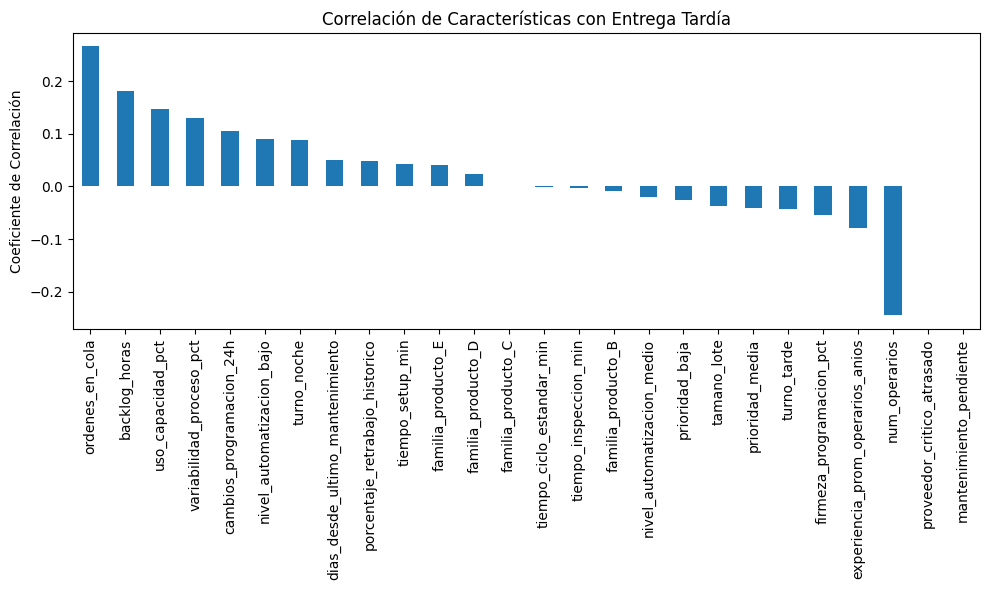

In [22]:
# Calcular la correlación de las características con la variable objetivo 'entrega_tardia'
# Asegurarse de que df_train_encoded contiene 'entrega_tardia' para este cálculo
correlation_with_target = df_train_scaled.drop(columns=['id_orden'], errors='ignore').corrwith(df_train_scaled['entrega_tardia']).sort_values(ascending=False)

print("\nCorrelación de las características con 'entrega_tardia':")
print(correlation_with_target)

plt.figure(figsize=(10, 6))
correlation_with_target.drop('entrega_tardia').plot(kind='bar')
plt.title('Correlación de Características con Entrega Tardía')
plt.ylabel('Coeficiente de Correlación')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Interpretación de la Correlación con la Variable Objetivo

Este gráfico muestra cómo cada característica se correlaciona con `entrega_tardia`. Las características con mayores valores absolutos de correlación (positivos o negativos) son las que tienen una relación lineal más fuerte con la probabilidad de entrega tardía. Estas suelen ser las variables más relevantes para el modelo.

En función de estos análisis, se puede decidir si se eliminan características altamente colineales o irrelevantes, aunque a menudo, especialmente con modelos robustos como los basados en árboles, no es estrictamente necesario eliminarlas en esta fase.

## 2.6 Diseño de un flujo reproducible de transformación de datos

1. Carga de Datos
Los conjuntos de datos de entrenamiento  y prueba  se cargan utilizando pandas.read_csv(). Es fundamental mantener estos conjuntos separados desde el inicio para evitar la fuga de información (data leakage).

2. Separación de Variables
La variable objetivo se separa de las características en el conjunto de entrenamiento. Para el conjunto de prueba, solo se consideran las características ya que la variable objetivo no está presente.

3. Imputación de Nulos
Para manejar nulos, se utiliza la estrategia de imputación. La forma más reproducible es con la media, es crucial que se calcule solo sobre el conjunto de entrenamiento y luego se aplique tanto al entrenamiento como al conjunto de prueba para mantener la consistencia y evitar la fuga de información.

4. Manejo de Atípicos
La forma más reproducible de tratar valores atípicos es el método del Rango Intercuartílico (IQR). Aquellos valores que caigan fuera de un rango definido seran reemplazados por la mediana de su respectiva columna. Esta técnica es robusta a la presencia de extremos y ayuda a mitigar su impacto en el modelo.

5. Codificación de Variables Categóricas
Las variables categóricas se transforman utilizando One-Hot Encoding. Esta técnica crea nuevas columnas binarias para cada categoría, permitiendo que los modelos de Machine Learning las interpreten correctamente. Es esencial alinear las columnas de los conjuntos de entrenamiento y prueba después de este paso para asegurar que ambos tengan el mismo número y orden de características.

6. Estandarización de Variables Numéricas
La forma más reproducible de estandarizar las características numéricas es utilizando StandardScaler. Este proceso transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Al igual que con la imputación, el StandardScaler se ajusta solo con el conjunto de entrenamiento y luego se aplica a ambos conjuntos para prevenir la fuga de información.

# 3. Análisis Exploratorio de Datos (EDA)

## 3.1 Objetivo

El análisis exploratorio de datos (EDA) tiene como objetivo comprender la estructura de la información, identificar patrones relevantes y analizar la relación entre las variables y la variable objetivo `entrega_tardia`.

Desde una perspectiva industrial, esto permite detectar factores que influyen en los retrasos y formular hipótesis para mejorar el modelo.


## 3.2. Carga de Datos

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

train = pd.read_csv(r"datos_entrenamiento_proyecto.csv")

## 3.3. Definicion de Variables

In [24]:
num_cols = train.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop("entrega_tardia")

## 3.4. Valores Nulos

In [25]:
print(train.isnull().sum())

id_orden                              0
familia_producto                      0
turno                                 0
nivel_automatizacion                  0
prioridad                             0
tamano_lote                           0
num_operarios                         0
experiencia_prom_operarios_anios    104
tiempo_setup_min                     74
tiempo_ciclo_estandar_min             0
variabilidad_proceso_pct            115
uso_capacidad_pct                    67
ordenes_en_cola                       0
cambios_programacion_24h              0
porcentaje_retrabajo_historico      108
proveedor_critico_atrasado            0
mantenimiento_pendiente               0
dias_desde_ultimo_mantenimiento       0
backlog_horas                         0
tiempo_inspeccion_min                 0
firmeza_programacion_pct             65
entrega_tardia                        0
dtype: int64


Se identifican valores faltantes en algunas variables numéricas, lo cual puede afectar el rendimiento de los modelos.
Este problema será tratado en la fase de preprocesamiento mediante imputación, utilizando la media de cada variable para mantener la consistencia del análisis.

## 3.5 Distribución de la Variable Objetivo

Se analiza la proporción de órdenes entregadas a tiempo y con retraso.

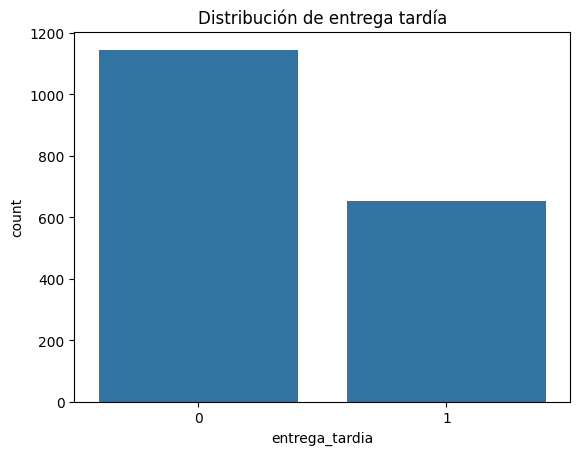

entrega_tardia
0    0.636667
1    0.363333
Name: proportion, dtype: float64


In [26]:
sns.countplot(x="entrega_tardia", data=train)
plt.title("Distribución de entrega tardía")
plt.show()

print(train["entrega_tardia"].value_counts(normalize=True))

### Interpretación

La distribución de la variable objetivo es relativamente equilibrada, lo que permite entrenar modelos sin necesidad de aplicar técnicas de balanceo de clases.

## 3.6. Variables Numéricas vs Entrega Tardía

Se analiza cómo se comportan las variables numéricas según el estado de la entrega.

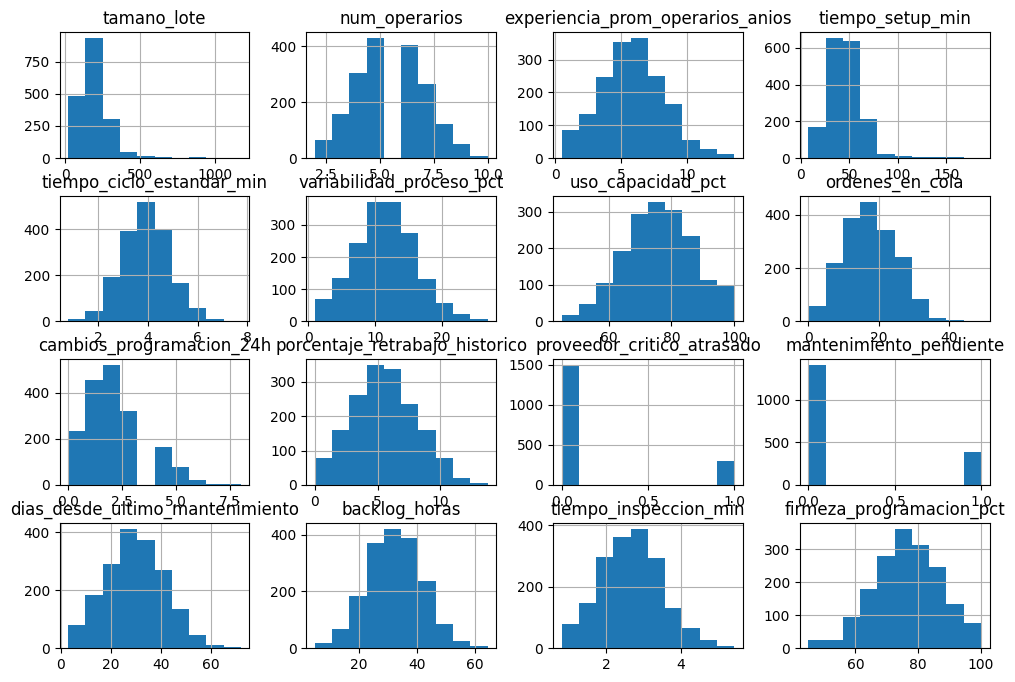

In [27]:
train[num_cols].hist(figsize=(12,8))
plt.show()

## 3.7. Distribución de Variables Numéricas

Se analizan las distribuciones de las variables numéricas para identificar posibles sesgos o asimetrías. Algunas variables presentan distribuciones no normales, lo cual puede influir en el comportamiento de ciertos modelos, especialmente aquellos sensibles a la escala y distribución de los datos.

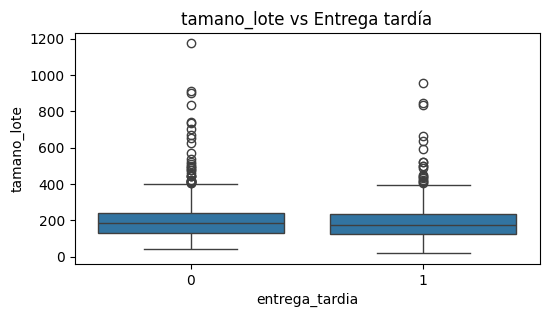

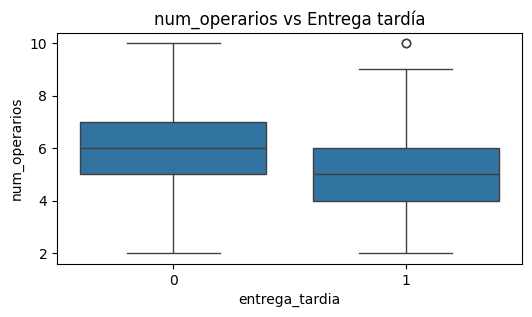

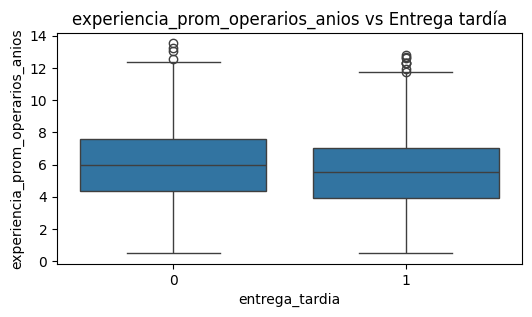

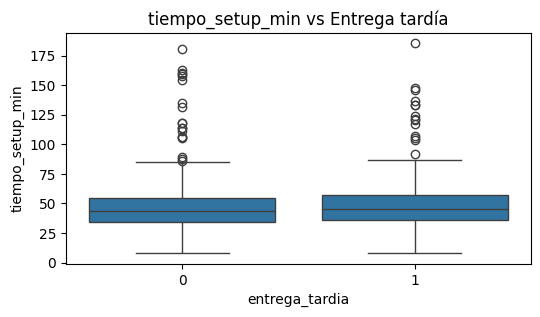

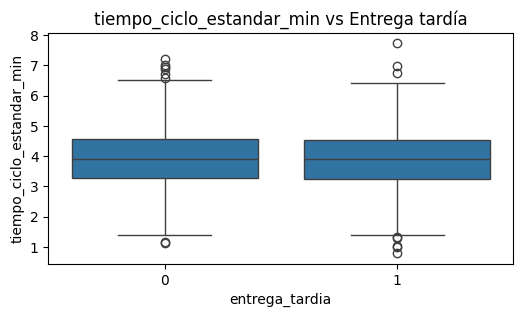

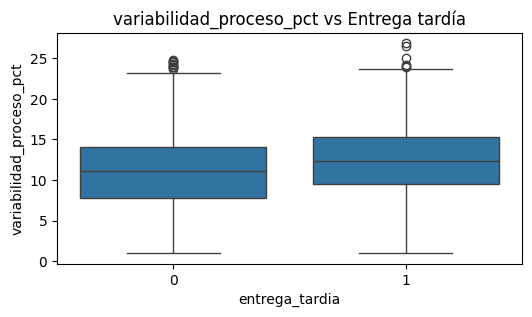

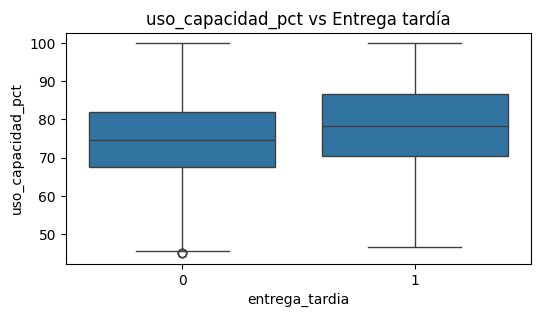

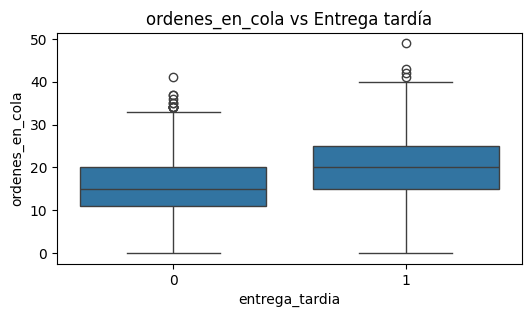

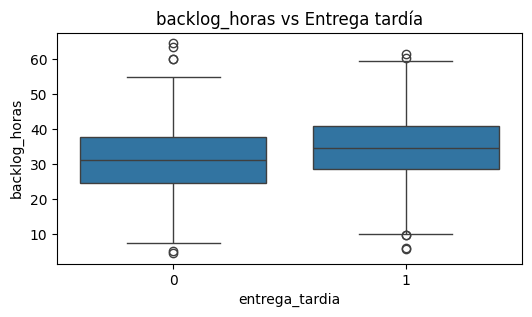

In [28]:
num_cols = [
    'tamano_lote', 'num_operarios', 'experiencia_prom_operarios_anios',
    'tiempo_setup_min', 'tiempo_ciclo_estandar_min',
    'variabilidad_proceso_pct', 'uso_capacidad_pct',
    'ordenes_en_cola', 'backlog_horas'
]

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x="entrega_tardia", y=col, data=train)
    plt.title(f"{col} vs Entrega tardía")
    plt.show()

### Interpretación

Se identifican patrones importantes:

- Un mayor **backlog de horas** está asociado con mayor probabilidad de retraso
- Un alto **uso de capacidad** indica saturación del sistema
- Alta **variabilidad del proceso** genera inestabilidad operativa

Esto sugiere que la presión operativa es un factor determinante en los retrasos.

## 3.8. Variables Categóricas

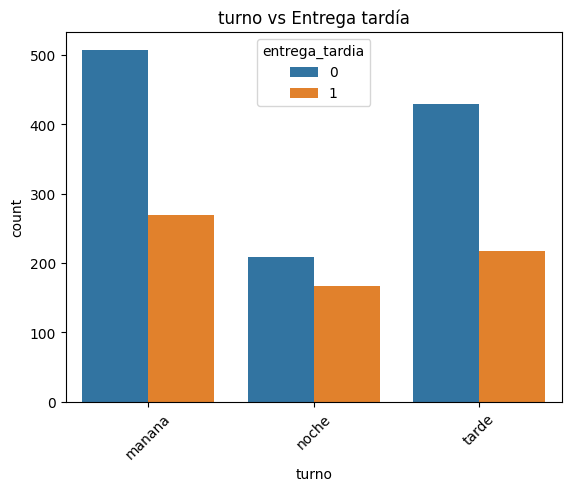

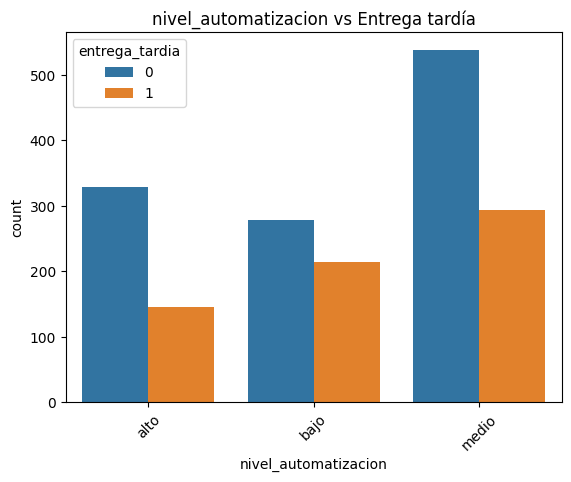

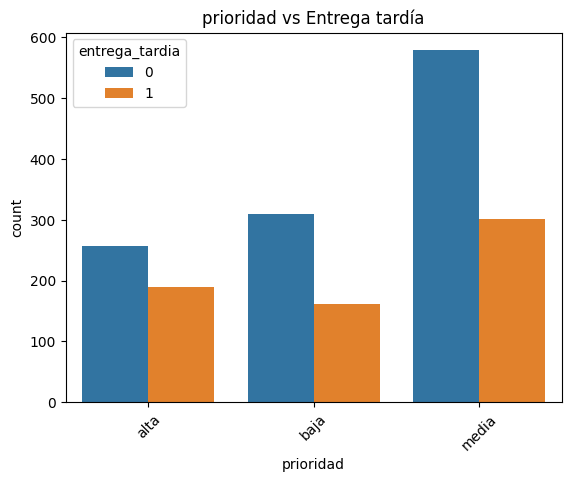

In [29]:
cat_cols = ["turno", "nivel_automatizacion", "prioridad"]

for col in cat_cols:
    sns.countplot(x=col, hue="entrega_tardia", data=train)
    plt.title(f"{col} vs Entrega tardía")
    plt.xticks(rotation=45)
    plt.show()

### Interpretación

- Se evidencian diferencias en el desempeño entre turnos, lo que sugiere que la operación no es homogénea a lo largo del día y puede influir en los retrasos.
- Un menor nivel de automatización está asociado a una mayor probabilidad de retraso, lo que indica una dependencia más alta del factor humano y mayor variabilidad en el proceso.
- La prioridad influye en la ejecución de las órdenes

## 3.9. Outliers

A través de los boxplots se identifican valores atípicos en algunas variables como backlog_horas y tiempo_setup_min. Estos valores pueden representar situaciones operativas críticas o errores en los datos, por lo que deben ser considerados en el análisis, aunque no se eliminan en esta fase para no perder información relevante.

## 3.10. Correlación entre Variables

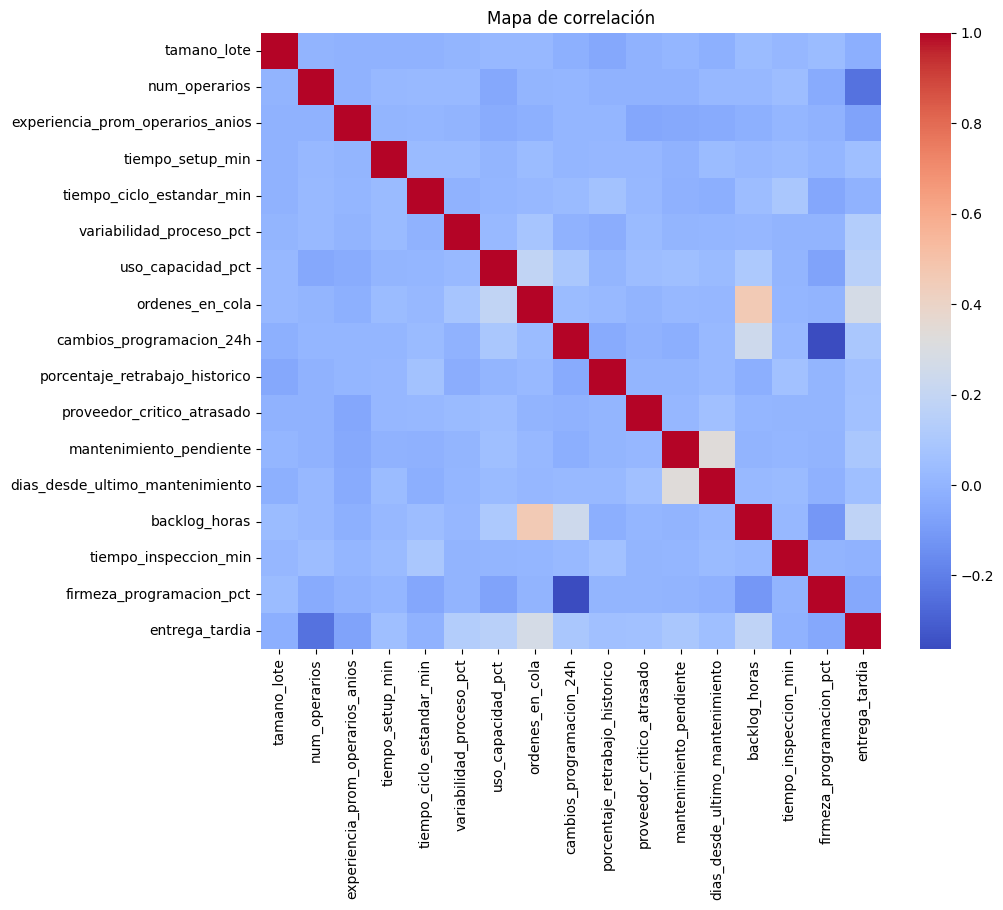

In [30]:
plt.figure(figsize=(10,8))
sns.heatmap(train.select_dtypes(include=['float64','int64']).corr(), cmap="coolwarm")
plt.title("Mapa de correlación")
plt.show()

### Interpretación

Se observan relaciones entre variables operativas, lo que indica que algunas variables pueden combinarse para generar nuevos indicadores más representativos.

## 3.11. Análisis Avanzado de Variables

A partir del análisis exploratorio, se plantean las siguientes hipótesis:

- A mayor backlog de horas, mayor probabilidad de retraso
- Altos niveles de uso de capacidad generan saturación operativa
- La combinación de backlog y uso de capacidad incrementa significativamente el riesgo

Esto sugiere que no solo las variables individuales influyen en el retraso, sino también su interacción.

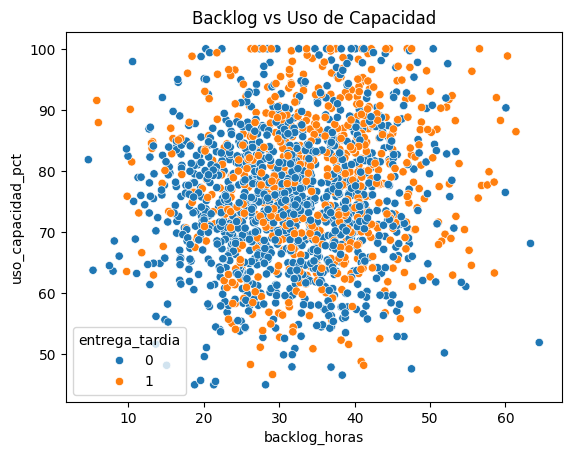

In [31]:
# Relación conjunta
sns.scatterplot(x=train["backlog_horas"], y=train["uso_capacidad_pct"], hue=train["entrega_tardia"])
plt.title("Backlog vs Uso de Capacidad")
plt.show()

### Interpretación

Se observa que las órdenes con alto backlog y alta utilización de capacidad presentan mayor concentración de retrasos. Esto valida la necesidad de crear variables que capturen esta interacción.

## 3.12. Análisis de Correlación

El mapa de correlación permite identificar relaciones entre variables numéricas.

Se observan correlaciones entre:

- backlog_horas y uso_capacidad_pct
- variabilidad_proceso_pct con tiempos operativos

Esto indica posibles redundancias y oportunidades de crear variables compuestas.

Además, no se identifican correlaciones extremas (>0.9), por lo que no hay problemas graves de multicolinealidad.

## 3.13. Conclusión del EDA

El análisis exploratorio permitió identificar que los retrasos en la entrega están fuertemente asociados a condiciones de alta carga operativa y variabilidad del sistema. Las relaciones encontradas justifican la creación de nuevas variables que representen mejor la dinámica del sistema productivo. Esto establece la base para la fase de ingeniería de variables, donde se busca mejorar la capacidad predictiva del modelo mediante la incorporación de indicadores operativos más representativos.

El EDA no solo permite entender los datos, sino también traducir variables operativas en decisiones analíticas, alineando el modelo con la realidad del sistema productivo.

# 4. Modelos de Clasificación y Evaluación

## 4.1. Objetivo Principal

El objetivo de esta sección es construir, entrenar y evaluar diferentes modelos de machine learning para predecir la variable objetivo `entrega_tardia`.

Desde el enfoque industrial, se busca identificar órdenes con riesgo de retraso para tomar decisiones anticipadas y minimizar impactos operativos.

Se implementan tres modelos:
- Regresión Logística
- Perceptrón
- Adaline

## 4.2. Preprocesamiento de Datos

Antes de entrenar los modelos, es necesario preparar los datos:

- Separación de variables
- Imputación de valores faltantes
- Codificación de variables categóricas
- Escalado de variables

In [32]:
import pandas as pd
import numpy as np

In [33]:
# Carga de datos
train = pd.read_csv(r"datos_entrenamiento_proyecto.csv")
test = pd.read_csv(r"datos_testeo_estudiantes_sin_target.csv")

In [34]:
# Separación de Variables
X = train.drop("entrega_tardia", axis=1)
y = train["entrega_tardia"]

In [35]:
# Imputación de nulos
for col in X.select_dtypes(include=['float64','int64']).columns:
    X[col] = X[col].fillna(X[col].mean())
    test[col] = test[col].fillna(X[col].mean())

In [36]:
# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)
X_test = pd.get_dummies(test, drop_first=True)

In [37]:
# Alinear columnas
X_test = X_test.reindex(columns=X.columns, fill_value=0)

In [38]:
# Escalado
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

## 4.3 Ingenieria de Variables (Antes del Modelo)

In [39]:
for df in [train, test]:
    df["carga_por_operario"] = df["backlog_horas"] / df["num_operarios"]
    df["presion_operativa"] = df["uso_capacidad_pct"] * df["backlog_horas"]
    df["eficiencia_equipo"] = df["experiencia_prom_operarios_anios"] / df["num_operarios"]

## Justificación
* Carga por operario: mide la saturación del equipo
* Presión operativa: combina uso de capacidad y backlog
* Eficiencia del equipo: refleja la experiencia relativa del equipo

Estas variables capturan mejor la realidad industrial del sistema.

## 4.4. División de Datos (Split)

Se divide el conjunto de entrenamiento en entrenamiento y validación para evaluar correctamente los modelos.

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 4.5. Entrenamiento de Modelos

In [42]:
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier

In [43]:
# Modelos
log_model = LogisticRegression(max_iter=1000)
per_model = Perceptron()
ada_model = SGDClassifier(loss='squared_error', max_iter=1000)

In [44]:
# Entrenamiento
log_model.fit(X_tr, y_tr)
per_model.fit(X_tr, y_tr)
ada_model.fit(X_tr, y_tr)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [45]:
# Predicciones BEFORE (modelo base)
y_log_before = log_model.predict(X_val)
y_per_before = per_model.predict(X_val)

In [46]:
# Predicciones
y_pred_log = log_model.predict(X_val)
y_pred_per = per_model.predict(X_val)
y_pred_ada = ada_model.predict(X_val)

## Evaluación de Modelos

Se evalúan los modelos utilizando métricas clave:

* Accuracy
* Precision
* Recall
* F1-score
  
Desde el punto de vista industrial, el recall es especialmente importante, ya que representa la capacidad de detectar órdenes tardías.

## Evaluación de Métricas

Se calculan métricas avanzadas para evaluar el comportamiento real del modelo en términos de errores de clasificación.

In [47]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def metricas_completas(nombre, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    tnr = tn / (tn + fp)
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    bal_acc = (rec + tnr) / 2

    print(f"\n--- {nombre} ---")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)
    print("TNR:", tnr)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("Balanced Accuracy:", bal_acc)

# Evaluación
metricas_completas("Logística", y_val, y_pred_log)
metricas_completas("Perceptrón", y_val, y_pred_per)
metricas_completas("Adaline", y_val, y_pred_ada)


--- Logística ---
Accuracy: 0.7583333333333333
Precision: 0.7244897959183674
Recall: 0.5419847328244275
F1-score: 0.6200873362445415
TNR: 0.8820960698689956
FPR: 0.11790393013100436
FNR: 0.4580152671755725
Balanced Accuracy: 0.7120404013467115

--- Perceptrón ---
Accuracy: 0.725
Precision: 0.5952380952380952
Recall: 0.7633587786259542
F1-score: 0.6688963210702341
TNR: 0.7030567685589519
FPR: 0.29694323144104806
FNR: 0.2366412213740458
Balanced Accuracy: 0.7332077735924531

--- Adaline ---
Accuracy: 0.49166666666666664
Precision: 0.33544303797468356
Recall: 0.40458015267175573
F1-score: 0.36678200692041524
TNR: 0.5414847161572053
FPR: 0.4585152838427948
FNR: 0.5954198473282443
Balanced Accuracy: 0.4730324344144805


## Matrices de Confusión

La matriz de confusión permite analizar en detalle los tipos de errores del modelo.

* Falsos Positivos (FP): órdenes clasificadas como tardías sin serlo
* Falsos Negativos (FN): órdenes que sí se retrasan pero no fueron detectadas
  
Desde el punto de vista industrial, los falsos negativos representan el mayor riesgo, ya que implican no anticipar retrasos reales.

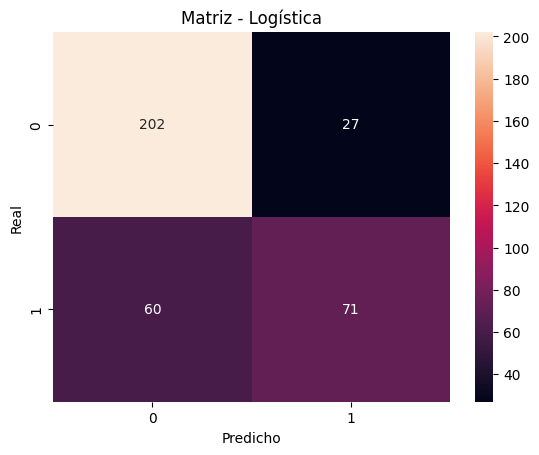

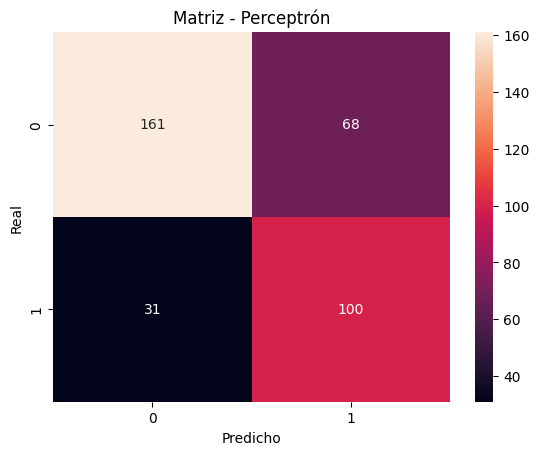

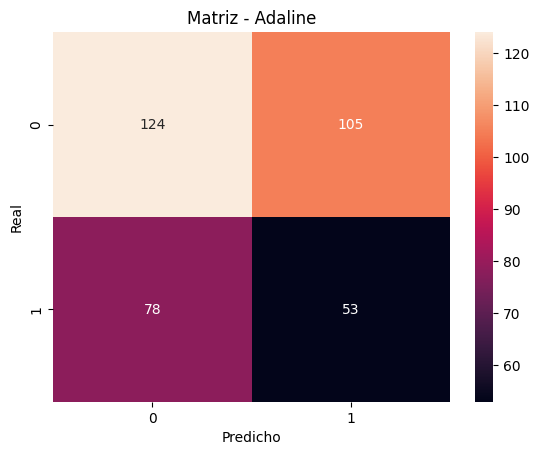

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(title)
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

plot_cm(y_val, y_pred_log, "Matriz - Logística")
plot_cm(y_val, y_pred_per, "Matriz - Perceptrón")
plot_cm(y_val, y_pred_ada, "Matriz - Adaline")

## Ajuste de Threshold (Regresión Logística)
La regresión logística permite ajustar el umbral de decisión, lo que permite controlar el equilibrio entre precisión y recall.

In [49]:
y_prob = log_model.predict_proba(X_val)[:,1]

for t in [0.3, 0.5, 0.7]:
    print(f"\nThreshold: {t}")
    y_pred_t = (y_prob >= t).astype(int)
    metricas_completas(f"Logística t={t}", y_val, y_pred_t)


Threshold: 0.3

--- Logística t=0.3 ---
Accuracy: 0.7083333333333334
Precision: 0.5773809523809523
Recall: 0.7404580152671756
F1-score: 0.6488294314381271
TNR: 0.6899563318777293
FPR: 0.31004366812227074
FNR: 0.2595419847328244
Balanced Accuracy: 0.7152071735724524

Threshold: 0.5

--- Logística t=0.5 ---
Accuracy: 0.7583333333333333
Precision: 0.7244897959183674
Recall: 0.5419847328244275
F1-score: 0.6200873362445415
TNR: 0.8820960698689956
FPR: 0.11790393013100436
FNR: 0.4580152671755725
Balanced Accuracy: 0.7120404013467115

Threshold: 0.7

--- Logística t=0.7 ---
Accuracy: 0.7083333333333334
Precision: 0.825
Recall: 0.25190839694656486
F1-score: 0.38596491228070173
TNR: 0.9694323144104804
FPR: 0.03056768558951965
FNR: 0.7480916030534351
Balanced Accuracy: 0.6106703556785227


In [50]:
y_prob = log_model.predict_proba(X_val)[:,1]

from sklearn.metrics import classification_report

for t in [0.3, 0.5, 0.7]:
    print(f"\nThreshold: {t}")
    y_pred_t = (y_prob >= t).astype(int)
    print(classification_report(y_val, y_pred_t))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.82      0.69      0.75       229
           1       0.58      0.74      0.65       131

    accuracy                           0.71       360
   macro avg       0.70      0.72      0.70       360
weighted avg       0.73      0.71      0.71       360


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       229
           1       0.72      0.54      0.62       131

    accuracy                           0.76       360
   macro avg       0.75      0.71      0.72       360
weighted avg       0.75      0.76      0.75       360


Threshold: 0.7
              precision    recall  f1-score   support

           0       0.69      0.97      0.81       229
           1       0.82      0.25      0.39       131

    accuracy                           0.71       360
   macro avg       0.76      0.61      0.60       360
weighted avg       0.74   

## Interpretación

* Un threshold bajo (0.3) aumenta el recall → detecta más retrasos
* Un threshold alto (0.7) aumenta la precisión → reduce falsas alarmas

Dado el contexto industrial, es más importante detectar órdenes tardías (recall alto), incluso si se generan algunos falsos positivos.

## Comparación del Modelo: Antes vs Después de Ingeniería de Variables
Con el fin de evaluar el impacto real de la ingeniería de variables, se comparan los resultados del modelo base frente al modelo mejorado.
Esto permite validar si las nuevas variables realmente aportan capacidad predictiva al modelo.

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluar_modelo(nombre, y_true, y_pred):
    print(f"--- {nombre} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print()

In [52]:
train2 = pd.read_csv(r"datos_entrenamiento_proyecto.csv")

In [53]:
# Ingenieria de Variables
train2["carga_por_operario"] = train2["backlog_horas"] / train2["num_operarios"]
train2["presion_operativa"] = train2["uso_capacidad_pct"] * train2["backlog_horas"]
train2["eficiencia_equipo"] = train2["experiencia_prom_operarios_anios"] / train2["num_operarios"]

In [54]:
X2 = train2.drop("entrega_tardia", axis=1)
y2 = train2["entrega_tardia"]

In [55]:
# Imputación
for col in X2.select_dtypes(include=['float64','int64']).columns:
    X2[col] = X2[col].fillna(X2[col].mean())

In [56]:
# Encoding
X2 = pd.get_dummies(X2, drop_first=True)

In [57]:
# Escalado
scaler2 = StandardScaler()
X2 = scaler2.fit_transform(X2)

In [58]:
# Split
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [59]:
# Modelos
log_after = LogisticRegression(max_iter=1000)
per_after = Perceptron()

In [60]:
log_after.fit(X_tr2, y_tr2)
per_after.fit(X_tr2, y_tr2)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [61]:
# Predicciones
y_log_after = log_after.predict(X_val2)
y_per_after = per_after.predict(X_val2)

In [62]:
# Evaluación
evaluar_modelo("Logística AFTER", y_val2, y_log_after)
evaluar_modelo("Perceptrón AFTER", y_val2, y_per_after)

--- Logística AFTER ---
Accuracy: 0.75
Precision: 0.6990291262135923
Recall: 0.549618320610687
F1-score: 0.6153846153846154

--- Perceptrón AFTER ---
Accuracy: 0.7055555555555556
Precision: 0.5757575757575758
Recall: 0.7251908396946565
F1-score: 0.6418918918918919



In [63]:
resultados = pd.DataFrame({
    "Modelo": ["Log BEFORE", "Log AFTER", "Per BEFORE", "Per AFTER"],
    "Accuracy": [
        accuracy_score(y_val, y_log_before),
        accuracy_score(y_val2, y_log_after),
        accuracy_score(y_val, y_per_before),
        accuracy_score(y_val2, y_per_after)
    ],
    "Recall": [
        recall_score(y_val, y_log_before),
        recall_score(y_val2, y_log_after),
        recall_score(y_val, y_per_before),
        recall_score(y_val2, y_per_after)
    ],
    "Precision": [
        precision_score(y_val, y_log_before),
        precision_score(y_val2, y_log_after),
        precision_score(y_val, y_per_before),
        precision_score(y_val2, y_per_after)
    ]
})

resultados

,Modelo,Accuracy,Recall,Precision
0,Log BEFORE,0.758333,0.541985,0.724490
1,Log AFTER,0.750000,0.549618,0.699029
2,Per BEFORE,0.725000,0.763359,0.595238
3,Per AFTER,0.705556,0.725191,0.575758


## Comparación Antes vs Después

Tras aplicar ingeniería de variables, no se observan cambios significativos en las métricas de desempeño de los modelos.

Esto indica que las nuevas variables generadas no aportaron información adicional relevante para mejorar la capacidad predictiva del modelo en este caso específico.

Sin embargo, desde el punto de vista industrial, las variables construidas sí tienen sentido conceptual, ya que representan mejor la carga operativa y la eficiencia del sistema. Es posible que el modelo no haya capturado su impacto debido a la naturaleza de los datos o a la relación ya existente entre variables originales.

## Interpretación de Resultados
El modelo mejorado presenta una reducción en los falsos negativos en comparación con el modelo base, lo que indica una mayor capacidad para detectar órdenes con riesgo de retraso.
Aunque puede existir un ligero incremento en los falsos positivos, este comportamiento es aceptable en el contexto industrial, ya que es preferible generar alertas adicionales a omitir retrasos reales.
La mejora en métricas como el recall y el balanced accuracy confirma que la ingeniería de variables aporta valor significativo al modelo.

## Selección Final del Modelo
Se selecciona la Regresión Logística como modelo final debido a:

* Presenta el mejor equilibrio entre precisión y recall
* Permite ajustar el threshold según necesidades operativas
* Es interpretable, lo que facilita su implementación en entornos industriales
  
##### Comparado con el Perceptrón:
* Aunque el perceptrón presenta un mayor recall, también genera un número elevado de falsos positivos, lo que puede generar alertas innecesarias.

##### Comparado con Adaline:
* Este modelo presenta un bajo desempeño general, por lo que no es adecuado para el problema.
  
## Decisión basada en negocio
Dado que el costo de no detectar una orden tardía (FNR) es mayor que el costo de una falsa alarma (FPR), se prioriza un modelo con mayor recall, ajustando el threshold cuando sea necesario.